Caricamento dati da dataset/data/window_000001.npz...


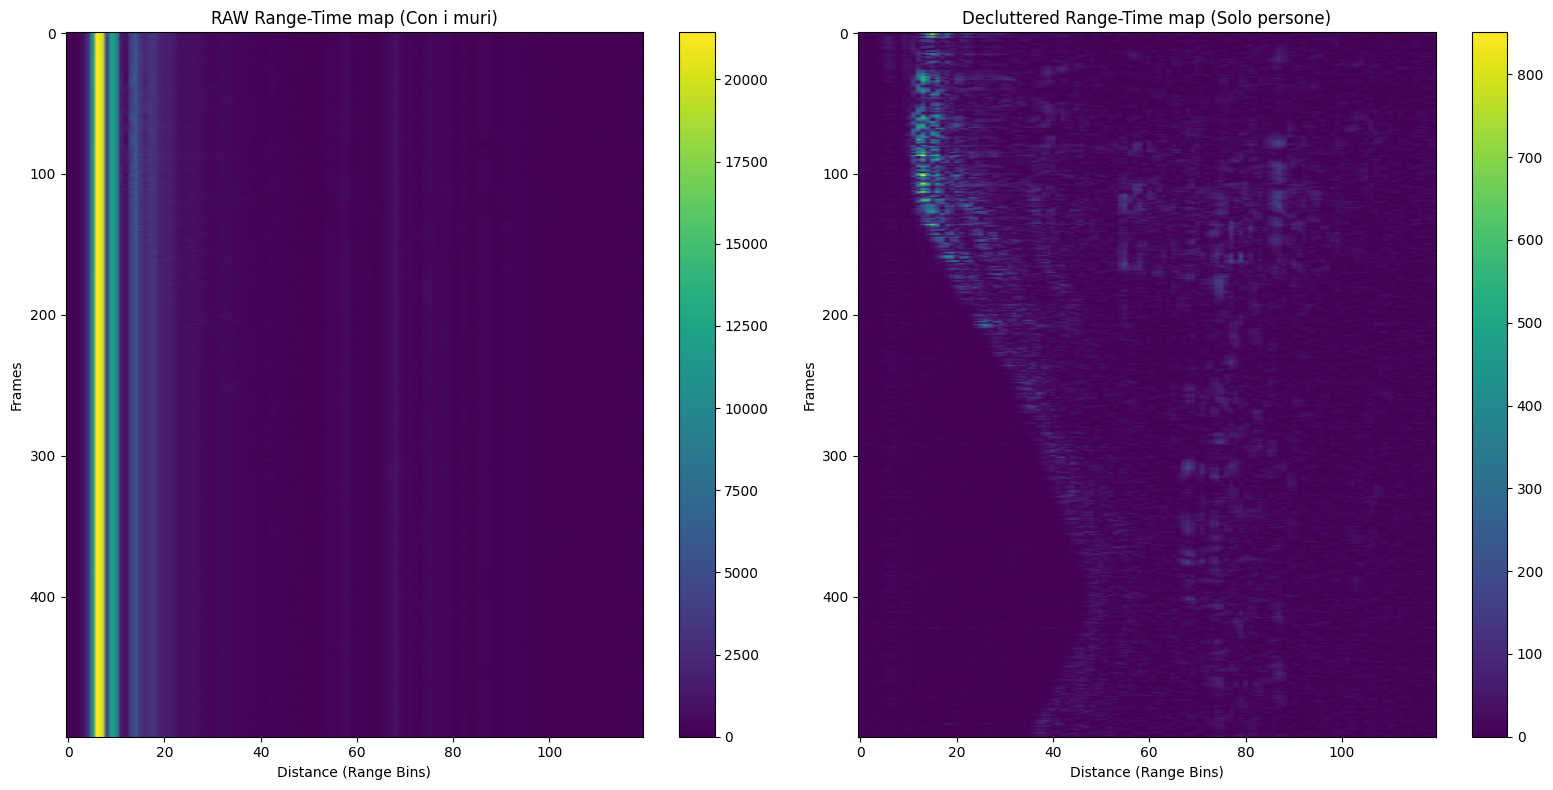

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

file_path = "dataset/data/window_000001.npz" 
print(f"Caricamento dati da {file_path}...")

data = np.load(file_path)
raw_iq = data['radar_cir_iq']

#Magnitude: sqrt(I^2 + Q^2)
#... means "all dimensions except the last one". 
#raw_iq[..., 0] è I e raw_iq[..., 1] è Q.
#magnitude has 4 D: (frames, radars, antennas, range_bins)

magnitude = np.sqrt(raw_iq[..., 0]**2 + raw_iq[..., 1]**2)

#Radar 0, antenna 0
radar_idx = 0
antenna_idx = 0

# Prendiamo solo i primi 500 frame per vedere bene il movimento (20 secondi a 25hz)
#we also select only the radar and antenna we want to analyze (radar_idx, antenna_idx)
#resulting shape: (500, 120) -> 500 frames, 120 range bins
#: significa tutto
raw_range_time = magnitude[:500, radar_idx, antenna_idx, :]

# 2. DECLUTTERING (EMA - Exponential Moving Average)
alpha = 0.05 # Peso del nuovo frame. Un valore piccolo significa che il "fondo" si aggiorna lentamente.
background = np.copy(raw_range_time[0]) # Inizializziamo il fondo col primo frame
decluttered_range_time = np.zeros_like(raw_range_time)

for t in range(raw_range_time.shape[0]):
    # A. Stima del fondo statico (Muri, mobili)
    background = alpha * raw_range_time[t] + (1 - alpha) * background
    
    # B. Sottrazione del fondo: il segnale "pulito" è quello grezzo meno il fondo
    decluttered_range_time[t] = raw_range_time[t] - background

# Prendiamo il valore assoluto della differenza
decluttered_range_time = np.abs(decluttered_range_time)

# 3. VISUALIZZAZIONE A CONFRONTO
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Grafico 1: RAW
im1 = axes[0].imshow(raw_range_time, aspect='auto', cmap='viridis')
axes[0].set_title('RAW Range-Time map (Con i muri)')
axes[0].set_ylabel('Frames')
axes[0].set_xlabel('Distance (Range Bins)')
fig.colorbar(im1, ax=axes[0])

# Grafico 2: DECLUTTERED
im2 = axes[1].imshow(decluttered_range_time, aspect='auto', cmap='viridis')
axes[1].set_title('Decluttered Range-Time map (Solo persone)')
axes[1].set_ylabel('Frames')
axes[1].set_xlabel('Distance (Range Bins)')
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

Generazione grafici per: dataset/data/window_000006.npz ...
20 secondi dall alto al basso (500 frames a 25hz), 120 bin di distanza da sinistra a destra.


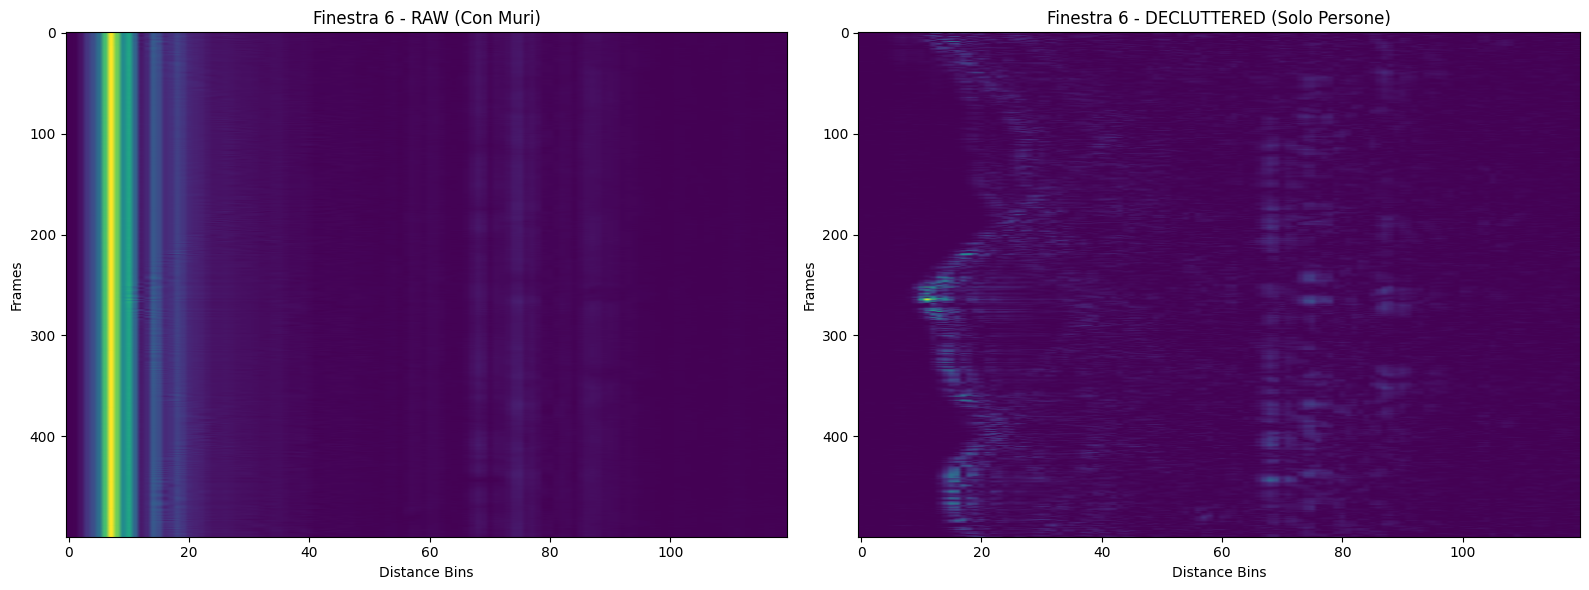

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def esplora_finestra(id_file):
    if not (0 <= id_file <= 23):
        print(f"Errore: L'ID {id_file} non è valido. Scegli tra 0 e 23.")
        return
        
    # Costruiamo il percorso esatto usando gli zero leading (es. 5 -> "data/window_000005.npz")
    file_path = f"dataset/data/window_{id_file:06d}.npz"
    print(f"Generazione grafici per: {file_path} ...")
    print(f"20 secondi dall alto al basso (500 frames a 25hz), 120 bin di distanza da sinistra a destra.")

    
    try:
        data = np.load(file_path)
    except FileNotFoundError:
        print(f"File {file_path} non trovato. Sicuro di essere nella cartella corretta?")
        return
        
    raw_iq = data['radar_cir_iq']
    
    # 1. Calcolo magnitudo (Radar 0, Antenna 0, Primi 500 frame per velocità)
    magnitude = np.sqrt(raw_iq[:500, 0, 0, :, 0]**2 + raw_iq[:500, 0, 0, :, 1]**2)
    
    # 2. Decluttering (Sottrazione fondo statico)
    alpha = 0.05 
    background = np.copy(magnitude[0]) 
    decluttered = np.zeros_like(magnitude)

    for t in range(magnitude.shape[0]):
        background = alpha * magnitude[t] + (1 - alpha) * background
        decluttered[t] = magnitude[t] - background
    decluttered = np.abs(decluttered)

    # 3. Disegno Grafici
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(magnitude, aspect='auto', cmap='viridis')
    axes[0].set_title(f'Finestra {id_file} - RAW (Con Muri)')
    axes[0].set_ylabel('Frames')
    axes[0].set_xlabel('Distance Bins')
    
    axes[1].imshow(decluttered, aspect='auto', cmap='viridis')
    axes[1].set_title(f'Finestra {id_file} - DECLUTTERED (Solo Persone)')
    axes[1].set_ylabel('Frames')
    axes[1].set_xlabel('Distance Bins')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# TEST: Cambia il numero qui sotto (0-23)
# ==========================================
esplora_finestra(6)

In [1]:
import numpy as np

# 1. CARICAMENTO DATI
# Sostituisci 'window_000000.npz' con il percorso reale del tuo file
file_path = 'dataset/data/window_000001.npz' 
print(f"Caricamento di {file_path} in corso...")
data = np.load(file_path)

# Estraiamo i dati grezzi dei radar
# Forma attesa: (Frames, 6 Radar, 3 Antenne, 120 Bins, 2 Canali I/Q)
raw_cir = data['radar_cir_iq']
print(f"Shape originale dei dati: {raw_cir.shape}")

# 2. SELEZIONE RADAR (Slicing)
# Ipotizziamo di voler usare solo 2 radar. 
# Ad esempio il radar all'indice 0 e quello all'indice 3.
radar_indices = [0, 3]
selected_cir = raw_cir[:, radar_indices, :, :, :]
print(f"Shape dopo aver tenuto solo 2 radar: {selected_cir.shape}")
# Risultato atteso: (Frames, 2, 3, 120, 2)

# 3. CALCOLO DELLA MAGNITUDO (Fusione di I e Q)
# I due canali I (In-phase) e Q (Quadrature) sono l'ultima dimensione (indice 4 o -1).
# Usiamo il teorema di Pitagora: sqrt(I^2 + Q^2)
I = selected_cir[:, :, :, :, 0]
Q = selected_cir[:, :, :, :, 1]
magnitude = np.sqrt(I**2 + Q**2)

print(f"Shape finale dell'Ampiezza (Magnitudo): {magnitude.shape}")
# Risultato atteso: (Frames, 2, 3, 120) - Nota che il '2' finale è sparito!

Caricamento di dataset/data/window_000001.npz in corso...
Shape originale dei dati: (7500, 6, 3, 120, 2)
Shape dopo aver tenuto solo 2 radar: (7500, 2, 3, 120, 2)
Shape finale dell'Ampiezza (Magnitudo): (7500, 2, 3, 120)
